In [1]:
!pip install transformers accelerate bitsandbytes groq scipy scikit-learn cerebras-cloud-sdk -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 7.8 MB/s eta 0:00:00


In [2]:
import shutil, os, json, time, warnings, zipfile, sys
import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
warnings.filterwarnings('ignore')

DATASET_PATH = "/kaggle/input/datasets/pramukhswami/dna-detectllm-orig"

def _setup_dna_module():
    for root, dirs, files in os.walk(DATASET_PATH):
        if 'dna_detectllm' in dirs:
            src = os.path.join(root, 'dna_detectllm')
            shutil.copytree(src, 'dna_detectllm', dirs_exist_ok=True)
            print(f'Copied folder from: {src}')
            return
        for fname in files:
            if fname == 'dna_detectllm.zip':
                zpath = os.path.join(root, fname)
                with zipfile.ZipFile(zpath) as zf:
                    zf.extractall('.')
                print(f'Extracted zip from: {zpath}')
                return

if not os.path.exists('dna_detectllm'):
    _setup_dna_module()

sys.path.insert(0, os.getcwd())
from dna_detectllm.metrics import sum_perplexity, entropy
os.environ['HF_TOKEN'] = 'YOUR_HF_TOKEN'

DEVICE_1 = 'cuda:0'
DEVICE_2 = 'cuda:1' if torch.cuda.device_count() > 1 else 'cuda:0'
print(f'GPUs: {torch.cuda.device_count()}')


Copied folder from: /kaggle/input/datasets/pramukhswami/dna-detectllm-orig/dna_detectllm
GPUs: 2


In [3]:
from kaggle_secrets import UserSecretsClient
secrets = UserSecretsClient()

# Try Cerebras first (free, no card needed), fall back to Groq
USE_CEREBRAS = False
try:
    from cerebras.cloud.sdk import Cerebras
    cerebras_client = Cerebras(api_key=secrets.get_secret("CEREBRAS_API_KEY"))
    # quick test
    r = cerebras_client.chat.completions.create(
        model="llama-3.3-70b",
        messages=[{"role": "user", "content": "Say hi."}],
        max_tokens=10
    )
    print(f"Cerebras OK: {r.choices[0].message.content.strip()}")
    USE_CEREBRAS = True
except Exception as e:
    print(f"Cerebras not available ({e}), falling back to Groq")
    from groq import Groq
    groq_client = Groq(api_key=secrets.get_secret("GROQ_API_KEY"))
    r = groq_client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[{"role": "user", "content": "Say hi."}],
        max_tokens=10
    )
    print(f"Groq OK: {r.choices[0].message.content.strip()}")

def llm_generate(prompt, max_tokens=450, temperature=0.7):
    if USE_CEREBRAS:
        resp = cerebras_client.chat.completions.create(
            model="llama-3.3-70b",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=temperature
        )
    else:
        resp = groq_client.chat.completions.create(
            model="llama-3.3-70b-versatile",
            messages=[{"role": "user", "content": prompt}],
            max_tokens=max_tokens,
            temperature=temperature
        )
    return resp.choices[0].message.content.strip()

print(f"Using: {'Cerebras' if USE_CEREBRAS else 'Groq'}")


Cerebras not available (Error code: 404 - {'message': 'Model llama-3.3-70b does not exist or you do not have access to it.', 'type': 'not_found_error', 'param': 'model', 'code': 'model_not_found'}), falling back to Groq
Groq OK: Hi. How can I help you today?
Using: Groq


In [4]:
!mkdir -p data
BASE = "https://raw.githubusercontent.com/Xiaoweizhu57/DNA-DetectLLM/main/Data"
!wget -q -O data/xsum_human.json "{BASE}/Collected%20data/xsum_human.json"

def load_texts(path):
    with open(path) as f:
        data = json.load(f)
    if isinstance(data, dict):
        for k in ["human_text", "machine_text", "text", "texts"]:
            if k in data: return data[k]
        first = list(data.keys())[0]
        if isinstance(data[first], list): return data[first]
    if isinstance(data, list):
        if isinstance(data[0], str): return data
        if isinstance(data[0], dict) and "text" in data[0]:
            return [d["text"] for d in data]
    raise ValueError(f"Cannot parse {path}")

N = 100
human_texts = load_texts("data/xsum_human.json")[:N]
print(f"Loaded {len(human_texts)} human texts")
print(f"Example: {human_texts[0][:200]}")


Loaded 100 human texts
Example: Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. The Ten Pieces project was announced last year as part of an initiative to inspi


In [5]:
# Paper uses text continuation prompts:
# give the first sentence of a news article + "Please continue."
# This is from Appendix C, Table 3 of the DNA-DetectLLM paper.

def get_first_sentence(text):
    for delim in ['. ', '! ', '? ']:
        idx = text.find(delim)
        if idx > 40:
            return text[:idx + 1]
    chunk = text[:120]
    return chunk[:chunk.rfind(' ')] if ' ' in chunk else chunk

AI_PROMPT = (
    "You are a news journalist. Continue the following news article naturally, "
    "keeping the same style, facts, and length as the original. "
    "Output only the continuation, nothing else.\n\n{sentence} Please continue."
)

HUMANIZE_PROMPT = (
    "You are given an AI-generated news article. "
    "Rewrite it so it reads like it was written by a human journalist. "
    "Vary sentence lengths and structure, use more natural transitions, "
    "avoid overly uniform phrasing, and keep the same factual content and length. "
    "Output only the rewritten article, nothing else.\n\nAI-generated article:\n{text}"
)

prompts = [AI_PROMPT.format(sentence=get_first_sentence(t)) for t in human_texts]

print("=== Sample prompt ===")
print(prompts[0])
print()
print("=== Original human text ===")
print(human_texts[0][:300])


=== Sample prompt ===
You are a news journalist. Continue the following news article naturally, keeping the same style, facts, and length as the original. Output only the continuation, nothing else.

Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. Please continue.

=== Original human text ===
Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. The Ten Pieces project was announced last year as part of an initiative to inspire primary school children to learn more about classical music. Each Prom will feature pupils playin


In [6]:
# Step 1: Generate AI text from human text prompts (same continuation approach as paper)
ai_texts = []
failed_gen = []

for i, prompt in enumerate(tqdm(prompts, desc="Generating AI texts")):
    try:
        result = llm_generate(prompt, max_tokens=450, temperature=0.7)
        ai_texts.append(result)
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{N} done")
        time.sleep(2.0)
    except Exception as e:
        print(f"  Failed {i}: {e}")
        failed_gen.append((i, str(e)))
        ai_texts.append(None)
        time.sleep(6)

n_ok = sum(1 for t in ai_texts if t is not None)
print(f"\nAI generation done. Success: {n_ok}/{N}. Failed: {len(failed_gen)}")


Generating AI texts:  19%|█▉        | 19/100 [00:51<03:36,  2.67s/it]

  20/100 done


Generating AI texts:  39%|███▉      | 39/100 [01:48<02:47,  2.75s/it]

  40/100 done


Generating AI texts:  59%|█████▉    | 59/100 [02:41<01:47,  2.62s/it]

...

  80/100 done


Generating AI texts:  99%|█████████▉| 99/100 [04:30<00:02,  2.64s/it]

  100/100 done


Generating AI texts: 100%|██████████| 100/100 [04:32<00:00,  2.73s/it]


AI generation done. Success: 100/100. Failed: 0


In [7]:
# Step 2: Humanize the AI-generated texts using the SAME model (same-family)
# This is the key experiment: Llama generates -> Llama humanizes
# Compare to previous triplet experiment: GPT-4 generated -> Llama humanized (cross-family)
humanized_texts = []
failed_hum = []

for i, ai_text in enumerate(tqdm(ai_texts, desc="Humanizing AI texts")):
    if ai_text is None:
        humanized_texts.append(None)
        continue
    try:
        result = llm_generate(HUMANIZE_PROMPT.format(text=ai_text), max_tokens=450, temperature=0.7)
        humanized_texts.append(result)
        if (i + 1) % 20 == 0:
            print(f"  {i+1}/{N} done")
        time.sleep(2.0)
    except Exception as e:
        print(f"  Failed {i}: {e}")
        failed_hum.append((i, str(e)))
        humanized_texts.append(None)
        time.sleep(6)

n_ok = sum(1 for t in humanized_texts if t is not None)
print(f"\nHumanization done. Success: {n_ok}/{N}. Failed: {len(failed_hum)}")

# Save all texts
with open("same_family_triplets.json", "w") as f:
    json.dump({
        "human": human_texts,
        "ai": ai_texts,
        "humanized": humanized_texts,
        "failed_gen": failed_gen,
        "failed_hum": failed_hum
    }, f, indent=2)
print("Saved same_family_triplets.json")


Humanizing AI texts:  19%|█▉        | 19/100 [00:54<03:48,  2.82s/it]

  20/100 done


Humanizing AI texts:  39%|███▉      | 39/100 [01:51<02:45,  2.72s/it]

  40/100 done


Humanizing AI texts:  59%|█████▉    | 59/100 [02:50<01:56,  2.83s/it]

...

  80/100 done


Humanizing AI texts:  99%|█████████▉| 99/100 [04:45<00:02,  2.81s/it]

  100/100 done


Humanizing AI texts: 100%|██████████| 100/100 [04:48<00:00,  2.88s/it]


Humanization done. Success: 100/100. Failed: 0
Saved same_family_triplets.json


In [8]:
print("=== HUMAN (original) ===")
print(human_texts[0][:350])
print("\n=== AI-GENERATED (Llama) ===")
print(ai_texts[0][:350] if ai_texts[0] else "FAILED")
print("\n=== HUMANIZED (Llama rewriting Llama) ===")
print(humanized_texts[0][:350] if humanized_texts[0] else "FAILED")


=== HUMAN (original) ===
Two special concerts at the Royal Albert Hall will see pupils perform their own response to 10 pieces of classic music. The Ten Pieces project was announced last year as part of an initiative to inspire primary school children to learn more about classical music. Each Prom will feature pupils playing music, as well as dance, film and animation. The

=== AI-GENERATED (Llama) ===
The performances, scheduled to take place in the summer, are the culmination of a nationwide project that has seen over 10,000 schoolchildren from across the UK engage with iconic works by composers such as Beethoven, Mozart, and Tchaikovsky. As part of the initiative, pupils have been encouraged to create their own musical interpretations, ranging

=== HUMANIZED (Llama rewriting Llama) ===
This summer, the Royal Albert Hall will play host to a pair of extraordinary concerts, the culmination of a nationwide project that has sparked the creativity of over 10,000 schoolchildren from every 

In [9]:
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type="nf4"
)

observer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b", quantization_config=quant_config,
    device_map={"": DEVICE_1}, low_cpu_mem_usage=True)
performer = AutoModelForCausalLM.from_pretrained(
    "tiiuae/falcon-7b-instruct", quantization_config=quant_config,
    device_map={"": DEVICE_2}, low_cpu_mem_usage=True)
observer.eval()
performer.eval()

tokenizer = AutoTokenizer.from_pretrained("tiiuae/falcon-7b")
tokenizer.pad_token = tokenizer.eos_token
MAX_LEN = 512

print(f"GPU 0: {torch.cuda.memory_allocated(0)/1e9:.1f} GB")
print(f"GPU 1: {torch.cuda.memory_allocated(1)/1e9:.1f} GB")


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


...

generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

GPU 0: 4.9 GB
GPU 1: 4.9 GB


In [10]:
@torch.inference_mode()
def compute_score(text):
    enc = tokenizer(text, return_tensors="pt", truncation=True,
                    max_length=MAX_LEN, return_token_type_ids=False)
    obs_logits = observer(**enc.to(DEVICE_1)).logits.float()
    perf_logits = performer(**enc.to(DEVICE_2)).logits.float()
    ppl = sum_perplexity(enc.to(perf_logits.device), perf_logits)
    x_ppl = entropy(obs_logits.to(DEVICE_1), perf_logits.to(DEVICE_1),
                    enc.to(DEVICE_1), tokenizer.pad_token_id)
    return float(ppl[0] / (2 * x_ppl[0]))

def score_list(texts, desc):
    scores = []
    for t in tqdm(texts, desc=desc):
        if t is None:
            scores.append(float('nan'))
        else:
            try: scores.append(compute_score(t))
            except: scores.append(float('nan'))
    return scores

print(f"Sanity: {compute_score('hello world'):.4f}")


Sanity: 0.8342


In [11]:
human_scores     = score_list(human_texts,     "Human")
ai_scores        = score_list(ai_texts,        "AI (Llama-generated)")
humanized_scores = score_list(humanized_texts, "Humanized (Llama→Llama)")

h_v  = [s for s in human_scores     if s == s]
a_v  = [s for s in ai_scores        if s == s]
hm_v = [s for s in humanized_scores if s == s]

print(f"{'Group':<25} {'Mean':>8} {'Std':>8} {'n':>5}")
print("-" * 50)
print(f"{'Human':<25} {np.mean(h_v):>8.4f} {np.std(h_v):>8.4f} {len(h_v):>5}")
print(f"{'AI (Llama-gen)':<25} {np.mean(a_v):>8.4f} {np.std(a_v):>8.4f} {len(a_v):>5}")
print(f"{'Humanized (Llama→Llama)':<25} {np.mean(hm_v):>8.4f} {np.std(hm_v):>8.4f} {len(hm_v):>5}")

valid_triplets = [(a, hm) for a, hm in zip(ai_scores, humanized_scores) if a == a and hm == hm]
shifts = [hm - a for a, hm in valid_triplets]
above = sum(1 for s in shifts if s > 0)
print(f"\nHuman - AI gap:        {np.mean(h_v) - np.mean(a_v):+.4f}")
print(f"Humanized - AI shift:  {np.mean(hm_v) - np.mean([t[0] for t in valid_triplets]):+.4f}")
print(f"Humanized > AI:        {above}/{len(shifts)} ({100*above/len(shifts):.1f}%)")




Human:   0%|          | 0/100 [00:00<?, ?it/s]

Human:   1%|          | 1/100 [00:01<02:35,  1.57s/it]

Human:   2%|▏         | 2/100 [00:02<02:20,  1.44s/it]

Human:   3%|▎         | 3/100 [00:04<02:31,  1.56s/it]

Human:   4%|▍         | 4/100 [00:06<02:35,  1.62s/it]

Human:   5%|▌         | 5/100 [00:07<02:13,  1.41s/it]

Human:   6%|▌         | 6/100 [00:09<02:22,  1.51s/it]

Human:   7%|▋         | 7/100 [00:10<02:05,  1.35s/it]

Human:   8%|▊         | 8/100 [00:11<02:05,  1.36s/it]

Human:   9%|▉         | 9/100 [00:12<02:05,  1.38s/it]

Human:  10%|█         | 10/100 [00:14<02:14,  1.49s/it]

Human:  11%|█         | 11/100 [00:16<02:14,  1.51s/it]

Human:  12%|█▏        | 12/100 [00:17<02:14,  1.53s/it]

Human:  13%|█▎        | 13/100 [00:19<02:18,  1.59s/it]

Human:  14%|█▍        | 14/100 [00:20<02:11,  1.53s/it]

Human:  15%|█▌        | 15/100 [00:22<02:15,  1.59s/it]

Human:  16%|█▌        | 16/100 [00:24<02:17,  1.64s/it]

Human:  17%|█▋        | 17/100 [00:25<02:00,  1

Group                         Mean      Std     n
--------------------------------------------------
Human                       0.6922   0.0224   100
AI (Llama-gen)              0.5525   0.0495   100
Humanized (Llama→Llama)     0.6014   0.0367   100

Human - AI gap:        +0.1397
Humanized - AI shift:  +0.0488
Humanized > AI:        95/100 (95.0%)


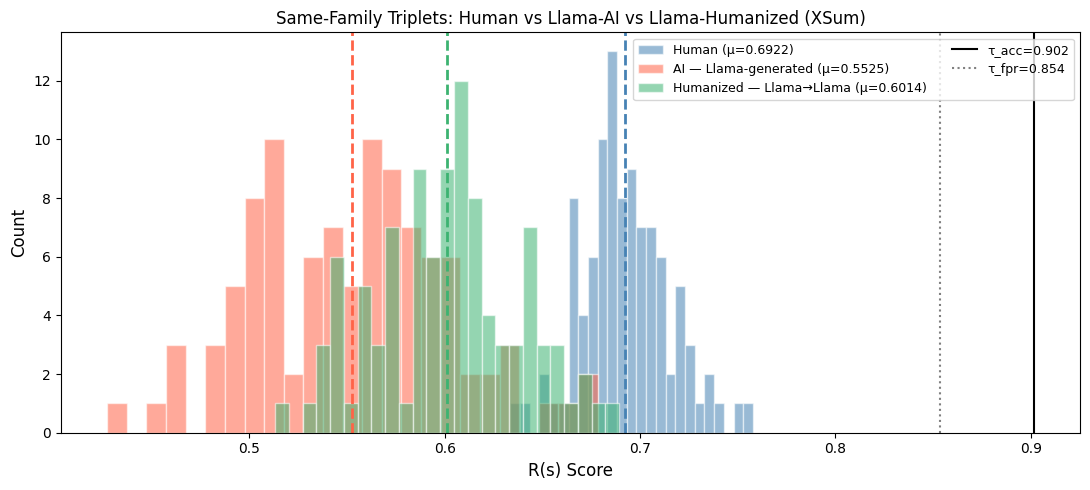

In [12]:
THRESH_ACCURACY = 0.9015310749276843
THRESH_FPR      = 0.8536432310785527

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(h_v,  bins=25, alpha=0.55, color='steelblue', edgecolor='white',
        label=f'Human (μ={np.mean(h_v):.4f})')
ax.hist(a_v,  bins=25, alpha=0.55, color='tomato',    edgecolor='white',
        label=f'AI — Llama-generated (μ={np.mean(a_v):.4f})')
ax.hist(hm_v, bins=25, alpha=0.55, color='mediumseagreen', edgecolor='white',
        label=f'Humanized — Llama→Llama (μ={np.mean(hm_v):.4f})')
for val, col in [(np.mean(h_v),'steelblue'),(np.mean(a_v),'tomato'),(np.mean(hm_v),'mediumseagreen')]:
    ax.axvline(val, color=col, ls='--', lw=2)
ax.axvline(THRESH_ACCURACY, color='black', ls='-',  lw=1.5, label=f'τ_acc={THRESH_ACCURACY:.3f}')
ax.axvline(THRESH_FPR,      color='grey',  ls=':',  lw=1.5, label=f'τ_fpr={THRESH_FPR:.3f}')
ax.set_xlabel('R(s) Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Same-Family Triplets: Human vs Llama-AI vs Llama-Humanized (XSum)', fontsize=12)
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('same_family_distributions.png', dpi=150)
plt.show()


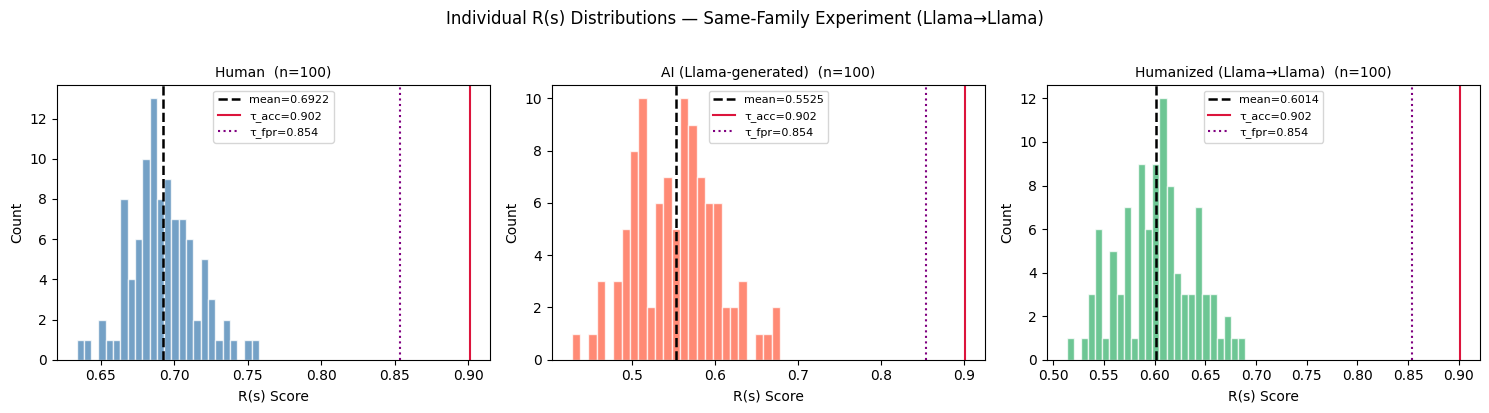

In [13]:
groups = [
    (h_v,  'Human',               'steelblue'),
    (a_v,  'AI (Llama-generated)','tomato'),
    (hm_v, 'Humanized (Llama→Llama)', 'mediumseagreen'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, (vals, label, color) in zip(axes, groups):
    ax.hist(vals, bins=25, color=color, alpha=0.75, edgecolor='white')
    ax.axvline(np.mean(vals),    color='black',  ls='--', lw=1.8, label=f'mean={np.mean(vals):.4f}')
    ax.axvline(THRESH_ACCURACY,  color='crimson',ls='-',  lw=1.5, label=f'τ_acc={THRESH_ACCURACY:.3f}')
    ax.axvline(THRESH_FPR,       color='purple', ls=':',  lw=1.5, label=f'τ_fpr={THRESH_FPR:.3f}')
    ax.set_title(f'{label}  (n={len(vals)})', fontsize=10)
    ax.set_xlabel('R(s) Score', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Individual R(s) Distributions — Same-Family Experiment (Llama→Llama)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('same_family_individual.png', dpi=150, bbox_inches='tight')
plt.show()


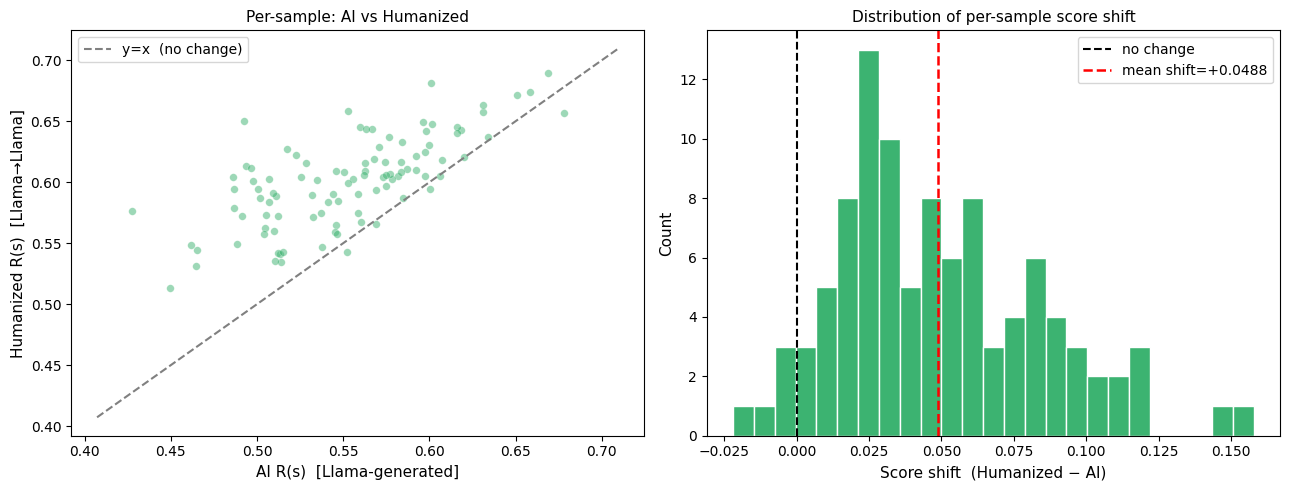

95/100 humanized texts scored HIGHER than their AI original (95.0%)


In [14]:
ai_p  = [t[0] for t in valid_triplets]
hm_p  = [t[1] for t in valid_triplets]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(ai_p, hm_p, alpha=0.5, s=30, c='mediumseagreen', edgecolors='white', lw=0.3)
lims = [min(min(ai_p), min(hm_p)) - 0.02, max(max(ai_p), max(hm_p)) + 0.02]
axes[0].plot(lims, lims, '--', color='gray', lw=1.5, label='y=x  (no change)')
axes[0].set_xlabel('AI R(s)  [Llama-generated]', fontsize=11)
axes[0].set_ylabel('Humanized R(s)  [Llama→Llama]', fontsize=11)
axes[0].set_title('Per-sample: AI vs Humanized', fontsize=11)
axes[0].legend(fontsize=10)

axes[1].hist(shifts, bins=25, color='mediumseagreen', edgecolor='white')
axes[1].axvline(0, color='black', ls='--', lw=1.5, label='no change')
axes[1].axvline(np.mean(shifts), color='red', ls='--', lw=1.8,
                label=f'mean shift={np.mean(shifts):+.4f}')
axes[1].set_xlabel('Score shift  (Humanized − AI)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Distribution of per-sample score shift', fontsize=11)
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('same_family_shift.png', dpi=150)
plt.show()
print(f"{above}/{len(shifts)} humanized texts scored HIGHER than their AI original ({100*above/len(shifts):.1f}%)")


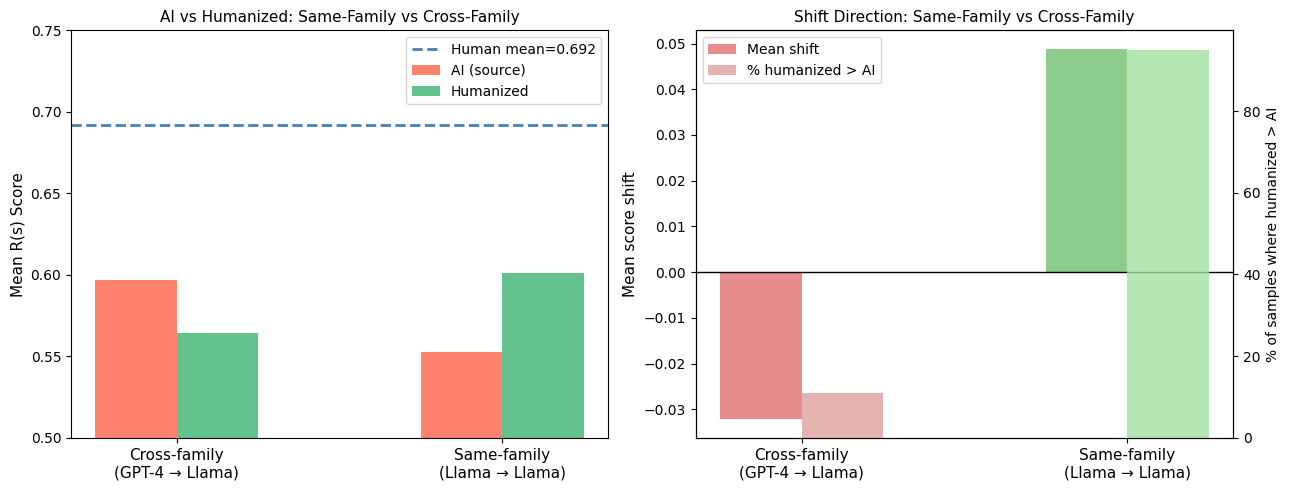


=== Same-Family vs Cross-Family Comparison ===
  Cross-family (GPT-4 → Llama)
    AI mean: 0.5968  Humanized mean: 0.5645
    Shift: -0.0322   % higher: 11.0%
  Same-family (Llama → Llama)
    AI mean: 0.5525  Humanized mean: 0.6014
    Shift: +0.0488   % higher: 95.0%


In [15]:
# Cross-family result from previous experiment (GPT-4 source -> Llama humanizer)
cross_family = {
    "ai_mean":        0.5968,
    "humanized_mean": 0.5645,
    "shift":          -0.0322,
    "pct_higher":     11.0,
    "label":          "Cross-family\n(GPT-4 → Llama)"
}
same_family = {
    "ai_mean":        np.mean(a_v),
    "humanized_mean": np.mean(hm_v),
    "shift":          float(np.mean(shifts)),
    "pct_higher":     float(100 * above / len(shifts)),
    "label":          "Same-family\n(Llama → Llama)"
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: mean scores comparison
x = np.arange(2)
width = 0.25
ai_vals  = [cross_family["ai_mean"],  same_family["ai_mean"]]
hm_vals  = [cross_family["humanized_mean"], same_family["humanized_mean"]]
xlabels  = [cross_family["label"], same_family["label"]]
h_mean   = np.mean(h_v)

bars1 = axes[0].bar(x - width/2, ai_vals,  width, label='AI (source)',      color='tomato',         alpha=0.8)
bars2 = axes[0].bar(x + width/2, hm_vals,  width, label='Humanized',        color='mediumseagreen', alpha=0.8)
axes[0].axhline(h_mean, color='steelblue', ls='--', lw=2, label=f'Human mean={h_mean:.3f}')
axes[0].set_xticks(x)
axes[0].set_xticklabels(xlabels, fontsize=11)
axes[0].set_ylabel('Mean R(s) Score', fontsize=11)
axes[0].set_title('AI vs Humanized: Same-Family vs Cross-Family', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].set_ylim(0.5, 0.75)

# Right: shift and % higher
shifts_vals = [cross_family["shift"], same_family["shift"]]
pct_vals    = [cross_family["pct_higher"], same_family["pct_higher"]]
colors_bar  = ['#e07070' if s < 0 else '#70c070' for s in shifts_vals]

ax2 = axes[1].twinx()
b1 = axes[1].bar(x - width/2, shifts_vals, width, color=colors_bar, alpha=0.8, label='Mean shift')
b2 = ax2.bar(x + width/2, pct_vals, width, color=['#e0a0a0','#a0e0a0'], alpha=0.8, label='% humanized > AI')
axes[1].axhline(0, color='black', ls='-', lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(xlabels, fontsize=11)
axes[1].set_ylabel('Mean score shift', fontsize=11)
ax2.set_ylabel('% of samples where humanized > AI', fontsize=10)
axes[1].set_title('Shift Direction: Same-Family vs Cross-Family', fontsize=11)
lines = [b1, b2]
axes[1].legend([b1, b2], ['Mean shift', '% humanized > AI'], fontsize=10, loc='upper left')

plt.tight_layout()
plt.savefig('same_vs_cross_family.png', dpi=150)
plt.show()

print("\n=== Same-Family vs Cross-Family Comparison ===")
for exp in [cross_family, same_family]:
    print(f"  {exp['label'].replace(chr(10),' ')}")
    print(f"    AI mean: {exp['ai_mean']:.4f}  Humanized mean: {exp['humanized_mean']:.4f}")
    print(f"    Shift: {exp['shift']:+.4f}   % higher: {exp['pct_higher']:.1f}%")


In [16]:
output = {
    "experiment": "Same-Family Triplets (Llama generates + Llama humanizes)",
    "model_used": "llama-3.3-70b (Cerebras/Groq)",
    "dataset": "XSum human texts",
    "n": N,
    "human_mean":      float(np.mean(h_v)),
    "human_std":       float(np.std(h_v)),
    "ai_mean":         float(np.mean(a_v)),
    "ai_std":          float(np.std(a_v)),
    "humanized_mean":  float(np.mean(hm_v)),
    "humanized_std":   float(np.std(hm_v)),
    "mean_shift":      float(np.mean(shifts)),
    "pct_humanized_higher": float(100 * above / len(shifts)),
    "n_valid_triplets": len(valid_triplets),
    "cross_family_ref": {
        "ai_mean": 0.5968, "humanized_mean": 0.5645,
        "shift": -0.0322, "pct_higher": 11.0
    },
    "human_scores":     human_scores,
    "ai_scores":        ai_scores,
    "humanized_scores": humanized_scores,
}

with open("same_family_results.json", "w") as f:
    json.dump(output, f, indent=2)

summary = {k: v for k, v in output.items()
           if k not in ['human_scores', 'ai_scores', 'humanized_scores']}
print(json.dumps(summary, indent=2))


{
  "experiment": "Same-Family Triplets (Llama generates + Llama humanizes)",
  "model_used": "llama-3.3-70b (Cerebras/Groq)",
  "dataset": "XSum human texts",
  "n": 100,
  "human_mean": 0.6922131139039993,
  "human_std": 0.022416883334228747,
  "ai_mean": 0.5525144222378731,
  "ai_std": 0.04945774188190699,
  "humanized_mean": 0.6013520687818528,
  "humanized_std": 0.036694625087881586,
  "mean_shift": 0.048837646543979644,
  "pct_humanized_higher": 95.0,
  "n_valid_triplets": 100,
  "cross_family_ref": {
    "ai_mean": 0.5968,
    "humanized_mean": 0.5645,
    "shift": -0.0322,
    "pct_higher": 11.0
  }
}


In [20]:
!mkdir same_triplet_results_final
!cp -r *.png *.json same_triplet_results_final
!zip -r same_triplet_results_final.zip same_triplet_results_final

  adding: same_triplet_results_final/ (stored 0%)
  adding: same_triplet_results_final/same_family_triplets.json (deflated 61%)
  adding: same_triplet_results_final/same_family_results.json (deflated 59%)
  adding: same_triplet_results_final/same_vs_cross_family.png (deflated 19%)
  adding: same_triplet_results_final/same_family_distributions.png (deflated 15%)
  adding: same_triplet_results_final/same_family_shift.png (deflated 13%)
  adding: same_triplet_results_final/same_family_individual.png (deflated 16%)


In [19]:
!ls

data			       same_family_shift.png
dna_detectllm		       same_family_triplets.json
same_family_distributions.png  same_triplet_results
same_family_individual.png     same_triplet_results.zip
same_family_results.json       same_vs_cross_family.png
